In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [17]:
df= pd.read_csv("leads_basic_details.csv")
df.head()

,lead_id,age,gender,current_city,current_education,parent_occupation,lead_gen_source
0,USR1001,16,FEMALE,Hyderabad,Intermediate,Private Employee,social_media
1,USR1002,20,MALE,Bengaluru,B.Tech,Business,user_referrals
2,USR1003,20,FEMALE,Visakhapatnam,B.Tech,Lawyer,user_referrals
3,USR1004,16,MALE,Mumbai,Intermediate,IT Employee,user_referrals
4,USR1005,16,MALE,Chennai,Intermediate,Government Employee,user_referrals


In [19]:
df.shape

(360, 7)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   lead_id            360 non-null    object
 1   age                360 non-null    int64 
 2   gender             360 non-null    object
 3   current_city       360 non-null    object
 4   current_education  360 non-null    object
 5   parent_occupation  360 non-null    object
 6   lead_gen_source    360 non-null    object
dtypes: int64(1), object(6)
memory usage: 19.8+ KB


In [21]:
df.describe()

,age
count,360.000000
mean,21.561111
std,11.555444
min,16.000000
25%,18.000000
50%,21.000000
75%,24.000000
max,211.000000


Data Cleaning

In [23]:
df.isnull().sum()

lead_id              0
age                  0
gender               0
current_city         0
current_education    0
parent_occupation    0
lead_gen_source      0
dtype: int64

In [24]:
df.dropna(inplace=True)

In [25]:
df.head()

,lead_id,age,gender,current_city,current_education,parent_occupation,lead_gen_source
0,USR1001,16,FEMALE,Hyderabad,Intermediate,Private Employee,social_media
1,USR1002,20,MALE,Bengaluru,B.Tech,Business,user_referrals
2,USR1003,20,FEMALE,Visakhapatnam,B.Tech,Lawyer,user_referrals
3,USR1004,16,MALE,Mumbai,Intermediate,IT Employee,user_referrals
4,USR1005,16,MALE,Chennai,Intermediate,Government Employee,user_referrals


In [26]:
df.drop_duplicates(inplace=True)

EDA Analysis

C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


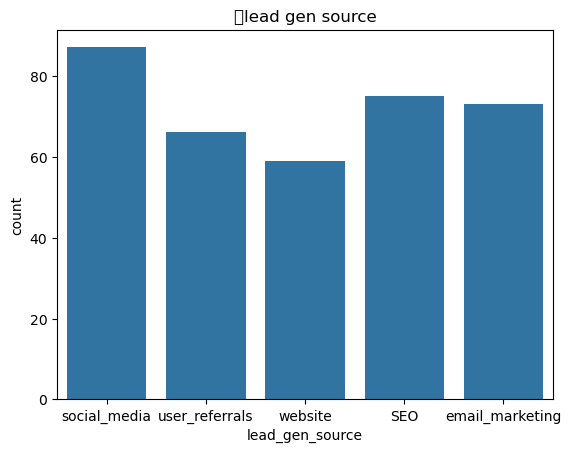

In [27]:
sns.countplot(x='lead_gen_source', data=df)
plt.title("	lead gen source")
plt.show()

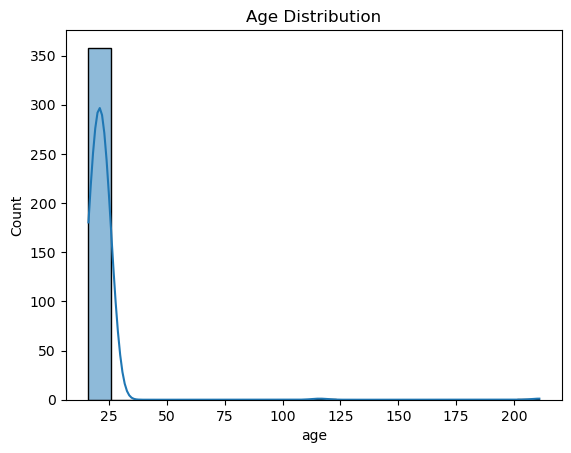

In [28]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

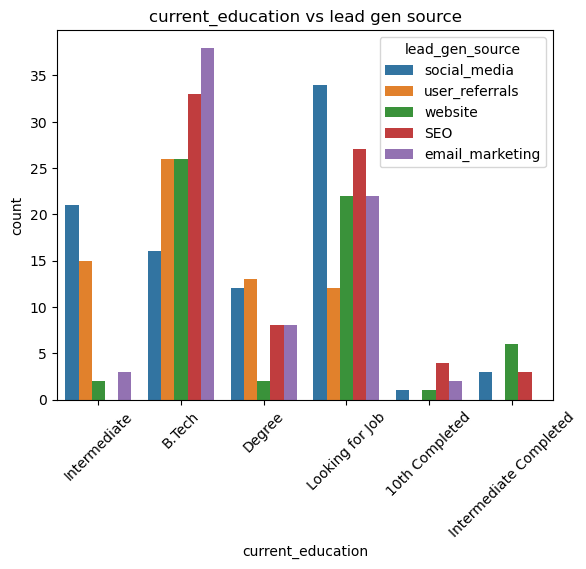

In [29]:
sns.countplot(x='current_education', hue='lead_gen_source', data=df)
plt.xticks(rotation=45)
plt.title("current_education vs lead gen source")
plt.show()

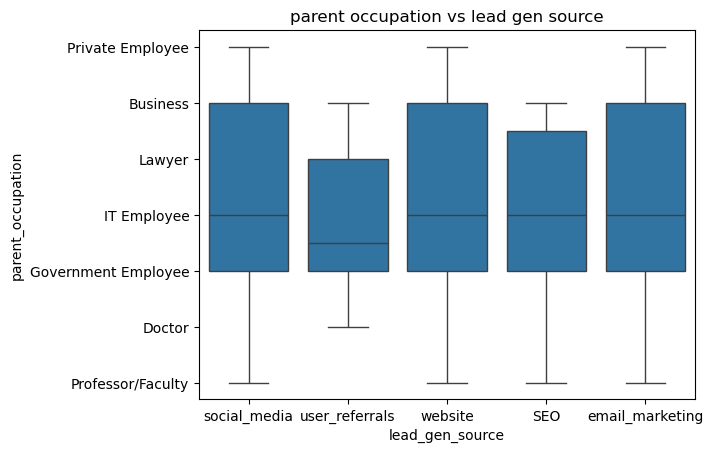

In [30]:
sns.boxplot(x='lead_gen_source', y='parent_occupation', data=df)
plt.title("parent occupation vs lead gen source")
plt.show()

In [33]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])


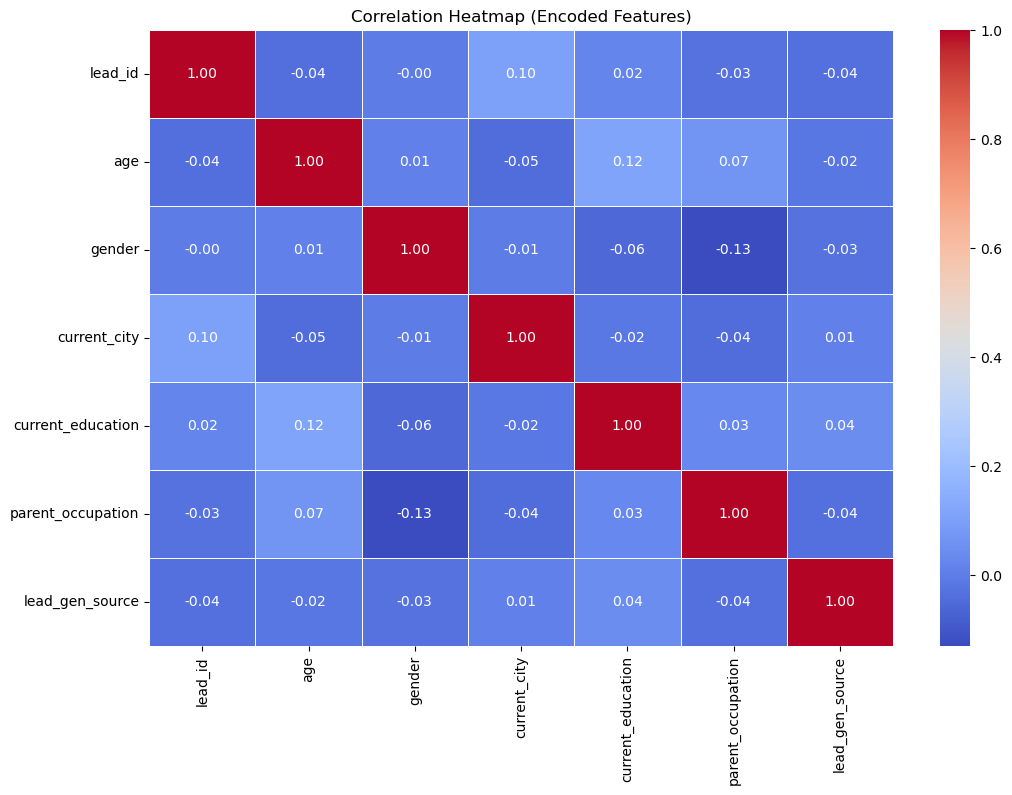

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Encoded Features)")
plt.show()



Feature,Train,Test and split data

In [81]:
df.drop('lead_id', axis=1, inplace=True)

In [82]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [83]:
X = df.drop('lead_gen_source', axis=1)
y = df['lead_gen_source']

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Hyperparameter Tuning - Employee Performance Prediction

In [85]:
log_reg = LogisticRegression(max_iter=1000)

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_log = GridSearchCV(
    log_reg,
    param_grid_log,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_log.fit(X_train, y_train)

best_log = grid_log.best_estimator_



In [86]:
y_pred_log = best_log.predict(X_test)
print("Best Parameters:", grid_log.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.2361111111111111
              precision    recall  f1-score   support

           0       0.10      0.17      0.12        12
           1       0.12      0.07      0.09        15
           2       0.43      0.48      0.45        21
           3       0.21      0.40      0.28        10
           4       0.00      0.00      0.00        14

    accuracy                           0.24        72
   macro avg       0.17      0.22      0.19        72
weighted avg       0.20      0.24      0.21        72



In [87]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

In [88]:
y_pred_rf = best_rf.predict(X_test)
print("Best Parameters:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.8194444444444444
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       0.92      0.73      0.81        15
           2       0.86      0.86      0.86        21
           3       0.67      0.80      0.73        10
           4       0.77      0.71      0.74        14

    accuracy                           0.82        72
   macro avg       0.81      0.82      0.81        72
weighted avg       0.83      0.82      0.82        72



In [89]:
svm = SVC()

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

In [90]:
y_pred_svm = best_svm.predict(X_test)
print("Best Parameters:", grid_svm.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Accuracy: 0.8055555555555556
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       0.91      0.67      0.77        15
           2       0.90      0.86      0.88        21
           3       0.62      0.80      0.70        10
           4       0.77      0.71      0.74        14

    accuracy                           0.81        72
   macro avg       0.80      0.81      0.79        72
weighted avg       0.82      0.81      0.81        72



In [91]:
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    knn,
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

In [92]:
y_pred_knn = best_knn.predict(X_test)
print("Best Parameters:", grid_knn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Accuracy: 0.8194444444444444
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       0.92      0.80      0.86        15
           2       0.81      0.81      0.81        21
           3       0.80      0.80      0.80        10
           4       0.71      0.71      0.71        14

    accuracy                           0.82        72
   macro avg       0.82      0.82      0.82        72
weighted avg       0.82      0.82      0.82        72



In [93]:
models = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

for model, acc in models.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.2361
Random Forest: 0.8194
SVM: 0.8056
KNN: 0.8194


In [63]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.25
Decision Tree Accuracy: 0.8055555555555556
Random Forest Accuracy: 0.8194444444444444


In [64]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8194444444444444
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       0.92      0.73      0.81        15
           2       0.90      0.86      0.88        21
           3       0.62      0.80      0.70        10
           4       0.77      0.71      0.74        14

    accuracy                           0.82        72
   macro avg       0.81      0.82      0.81        72
weighted avg       0.83      0.82      0.82        72



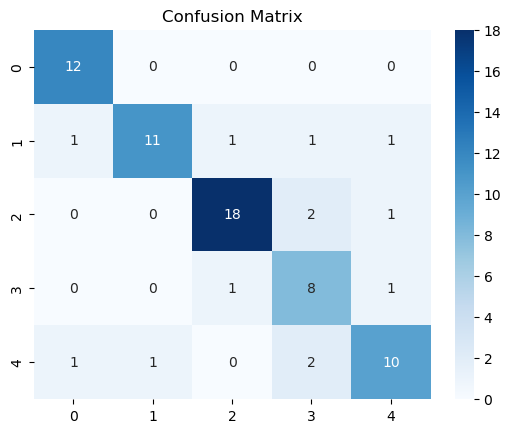

In [46]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()